# Finding patient subgroups

Patients with the same diagnosis or in the same unit can follow very different courses.
This tutorial finds such subgroups without any outcome information in the first 48 hours of 11,988 ICU stays of the PhysioNet 2012 challenge {cite}`silva2012predicting` {cite}`goldberger2000physiobank`.
We embed the hourly time series of every patient, cluster patients with similar courses, characterise the clusters by their measurements and relate them to in-hospital death.

## Environment setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import ehrapy as ep
import ehrdata as ed
import numpy as np

ep.settings.verbosity = "error"

In [2]:
%matplotlib inline

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
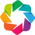

In [3]:
import holoviews as hv

hv.extension("bokeh")

## Data

The PhysioNet 2012 data holds 37 variables recorded hourly, so `.X` has the shape patients × variables × hours.
Static information such as age, ICU type and the outcome `In-hospital_death` is in `obs`.

In [4]:
edata = ed.dt.physionet2012()
edata

EHRData object with n_obs × n_vars × n_t = 11988 × 37 × 48
    obs: 'set', 'Age', 'Gender', 'Height', 'ICUType', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death'
    var: 'Parameter'
    tem: '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47'
    shape of .X: (11988, 37, 48)

Some recorded values are impossible, such as a heart rate or blood pressure of 0 or a pH of 735.
After scaling, a single such value would dominate the distance between two patients, so we set them to missing.

:::{seealso}
The {doc}`cohort tutorial </tutorials/notebooks/cohort>` shows how to find such values and how to define a cohort before clustering it.
:::

In [5]:
pressures = ["MAP", "SysABP", "DiasABP", "NIMAP", "NISysABP", "NIDiasABP"]
plausible = {
    "HR": (1, 300),
    **dict.fromkeys(pressures, (1, 300)),
    "Temp": (25, 45),
    "pH": (6.5, 8),
    "Weight": (20, 300),
}
for var, (low, high) in plausible.items():
    values = edata.X[:, edata.var_names.get_loc(var)]
    values[(values < low) | (values > high)] = np.nan

Variables measured in only a few patients say little about most of them, so we keep the variables measured in at least half of the patients.
`MechVent` is only recorded when a patient is ventilated, so a missing value means no ventilation.

In [6]:
ep.pp.qc_metrics(edata)
edata = edata[:, edata.var["measured_obs_pct"] >= 50].copy()
ep.pp.explicit_impute(edata, replacement={"MechVent": 0})
edata.var_names.tolist()

['BUN',
 'Creatinine',
 'DiasABP',
 'FiO2',
 'GCS',
 'Glucose',
 'HCO3',
 'HCT',
 'HR',
 'K',
 'Lactate',
 'MAP',
 'MechVent',
 'Mg',
 'NIDiasABP',
 'NIMAP',
 'NISysABP',
 'Na',
 'PaCO2',
 'PaO2',
 'Platelets',
 'SysABP',
 'Temp',
 'Urine',
 'WBC',
 'Weight',
 'pH']

## Embedding the time series

The embedding needs a value for every variable and hour.
{func}`~ehrapy.preprocessing.locf_impute` carries the last value of every variable forward and fills the hours before the first value with the mean of the variable.
We impute into a layer, so that `.X` keeps the observed values.

{func}`~ehrapy.preprocessing.scale_norm` then gives every variable a mean of 0 and a standard deviation of 1 across patients and hours, so that all variables contribute equally to the distances between patients.
We scale into a second layer and keep the imputed values in their original units to describe the clusters later.

:::{admonition} Which normalizer?
:class: tip
Use {func}`~ehrapy.preprocessing.scale_norm` before an embedding.
Use {func}`~ehrapy.preprocessing.robust_scale_norm` if extreme values remain, and {func}`~ehrapy.preprocessing.log_norm` first for strongly right-skewed variables such as creatinine.
:::

In [7]:
edata.layers["imputed"] = edata.X.copy()
ep.pp.locf_impute(edata, layer="imputed", fallback_method="mean")
edata.layers["scaled"] = edata.layers["imputed"].copy()
ep.pp.scale_norm(edata, layer="scaled")

{func}`~ehrapy.preprocessing.pca` runs directly on the 3D data by treating every combination of variable and hour as a feature, which is known as unfolded or multiway PCA.

:::{warning}
Leave the outcome and everything recorded after the first 48 hours, such as `Length_of_stay` and `Survival`, out of the embedding.
Otherwise the clusters relate to death by construction.
:::

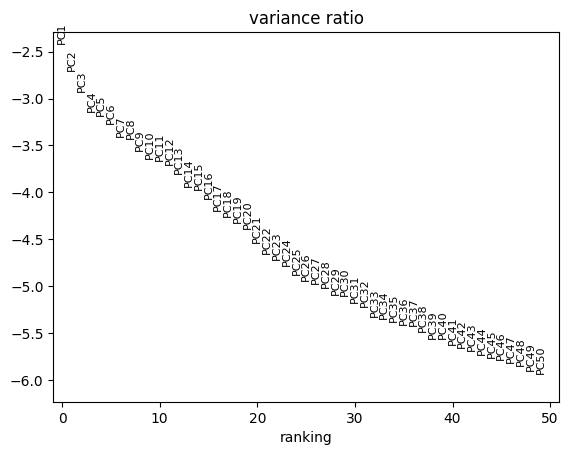

In [8]:
ep.pp.pca(edata, layer="scaled")
ep.pl.pca_variance_ratio(edata, n_pcs=50, log=True)

The first component explains 9% of the variance, and the explained variance falls smoothly without a clear elbow, so we keep all 50 components, which together explain 79%.
{func}`~ehrapy.preprocessing.neighbors` connects every patient to the 15 patients with the most similar time series.

In [9]:
ep.pp.neighbors(edata, n_pcs=50)

:::{admonition} Euclidean distance or dynamic time warping?
:class: note
The Euclidean distance between principal components compares patients hour by hour.
`metric="dtw"` instead aligns time series that are shifted in time, such as the same deterioration in hour 5 of one patient and hour 20 of another, and works on the 3D `.X` with its missing values.
It is worth it for small cohorts in which such shifts matter, since every comparison aligns all hours of every variable and takes far longer.
:::

{func}`~ehrapy.tools.umap` embeds the neighborhood graph in two dimensions {cite}`McInnes2018`.
Coloring it by the three sets of the challenge checks for a batch effect.

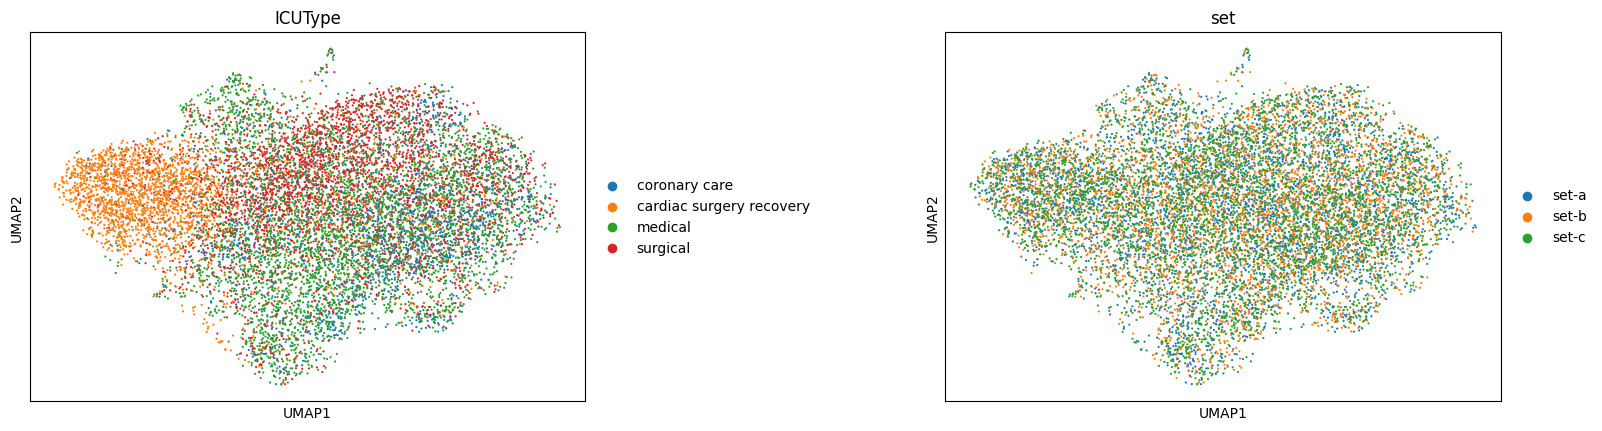

In [10]:
ep.tl.umap(edata)
ep.pl.umap(edata, color=["ICUType", "set"], wspace=0.5)

Patients from the cardiac surgery recovery unit form their own region on the left, while the other ICU types overlap.
The three sets mix evenly, as they should for random splits of the same data.

:::{note}
If patients separated by a technical batch such as the hospital, {func}`~ehrapy.preprocessing.combat` can remove it from summarized measurements before the embedding.
:::

## Clustering

{func}`~ehrapy.tools.leiden` finds groups of patients that are more connected to each other in the neighborhood graph than to the rest {cite}`Traag2019`.

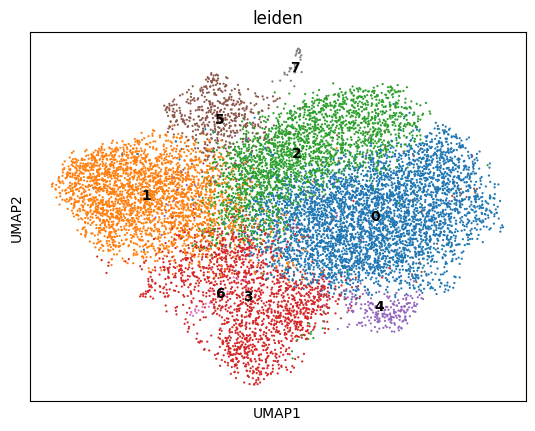

In [11]:
ep.tl.leiden(edata, resolution=0.5)
ep.pl.umap(edata, color="leiden", legend_loc="on data")

:::{important}
Leiden finds clusters at every resolution, and a higher resolution gives more and smaller clusters.
Choose the resolution by whether the clusters are clinically meaningful, and trust subgroups that persist across resolutions and random states.
:::

## Characterising the clusters

To describe the clusters in clinical units, {func}`~ehrapy.preprocessing.summarize_measurements` reduces the imputed time series to the mean of every variable on the first and the second day.
It keeps `obs`, so the summary carries the cluster of every patient.

:::{note}
Patients in whom a variable was never measured get its mean, which pulls the cluster means of rarely measured variables such as lactate towards the overall mean.
:::

In [12]:
summary = ep.pp.summarize_measurements(
    edata, layer="imputed", statistics=["mean"], tem_names={"day1": slice(0, 24), "day2": slice(24, 48)}
)
summary

EHRData object with n_obs × n_vars × n_t = 11988 × 54 × 1
    obs: 'set', 'Age', 'Gender', 'Height', 'ICUType', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death', 'missing_values_abs', 'missing_values_pct', 'entropy_of_missingness', 'measured_timepoints_abs', 'measured_timepoints_pct', 'first_measured_time', 'last_measured_time', 'leiden'
    shape of .X: (11988, 54)

{func}`~ehrapy.tools.rank_features_groups` tests every summary feature in every cluster against all other patients, and {func}`~ehrapy.get.rank_features_groups_df` returns the results as a table.

In [13]:
ep.tl.rank_features_groups(summary, groupby="leiden")
ranked = ep.get.rank_features_groups_df(summary, group=None, pval_cutoff=0.05)
ranked.groupby("group").head(3)[["group", "names", "scores", "logfoldchanges", "pvals_adj"]]

,group,names,scores,logfoldchanges,pvals_adj
0,0,GCS_mean_day1,63.270325,0.389673,0.000000e+00
1,0,MechVent_mean_day1,-64.017754,-1.829765,0.000000e+00
2,0,GCS_mean_day2,36.493740,0.235935,4.805558e-275
53,1,MAP_mean_day1,-47.311489,-0.149139,0.000000e+00
54,1,SysABP_mean_day1,-42.966732,-0.123411,0.000000e+00
55,1,MAP_mean_day2,-43.644291,-0.184867,0.000000e+00
102,2,SysABP_mean_day2,44.781448,0.200873,0.000000e+00
103,2,MAP_mean_day2,44.070976,0.219750,0.000000e+00
104,2,DiasABP_mean_day2,39.830975,0.231693,3.968631e-276
153,3,BUN_mean_day2,50.701202,1.486134,0.000000e+00


A positive score means that the feature is higher in the cluster than in the other patients.
{func}`~ehrapy.plot.dotplot` shows the two top features of every cluster next to the ICU types.
{func}`~ehrdata.move_to_x` copies the ICU type into the features, and {func}`~ehrapy.preprocessing.encode` turns every category into a feature that is 1 for patients of that ICU type and 0 otherwise, so the size of its dots is the share of patients from that ICU.

:::{seealso}
Encoded categorical variables can also enter an embedding.
For data with many categorical variables, {func}`~ehrapy.tools.famd` embeds numeric and categorical variables together.
:::

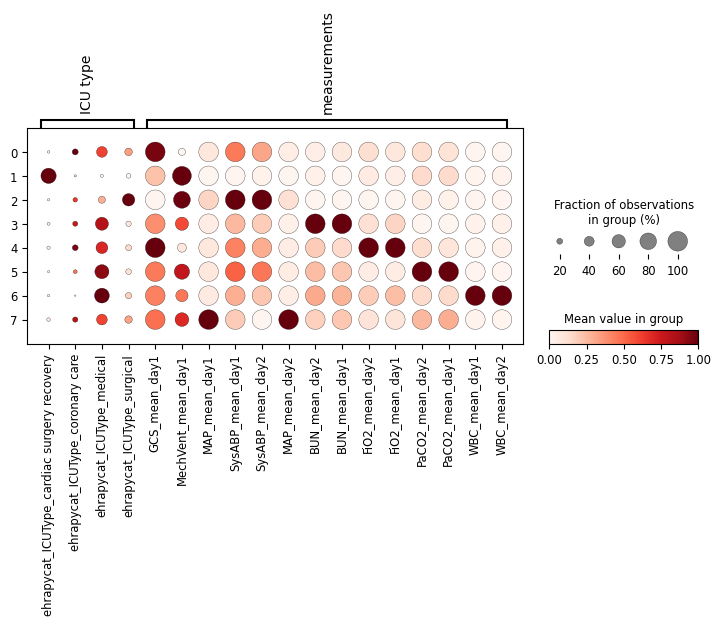

In [14]:
summary = ep.pp.encode(ed.move_to_x(summary, ["ICUType"], copy_columns=True), encodings={"one-hot": ["ICUType"]})
icu_types = [name for name in summary.var_names if name.startswith("ehrapycat_ICUType")]
top_features = ranked.groupby("group").head(2)["names"].unique().tolist()
ep.pl.dotplot(
    summary, var_names={"ICU type": icu_types, "measurements": top_features}, groupby="leiden", standard_scale="var"
)

`MechVent_mean` is the share of hours a patient was ventilated.
Cluster 1 holds most cardiac surgery recovery patients, with lower blood pressures and ventilation on the first day after surgery.
Cluster 0 is alert and rarely ventilated, while cluster 2 has higher blood pressures and the lowest GCS.
Cluster 3 has high BUN and creatinine, signs of kidney failure, cluster 4 needs a high fraction of inspired oxygen (FiO2), and cluster 5 has high PaCO2 and bicarbonate (HCO3), the pattern of chronic lung disease.
The two smallest clusters are defined by extreme values: cluster 6 by a mean white blood cell count of over 100, and cluster 7 by mean arterial pressures of up to 298 mmHg, which are likely recording errors within the plausible range set above.

:::{tip}
Check small clusters for data errors before interpreting them, since a few extreme values can pull patients into a cluster of their own.
:::

## Clusters and in-hospital death

None of the steps above used the outcome, so we can now ask whether the subgroups differ in how many patients died in hospital.

In [15]:
edata.obs.groupby("leiden", observed=True).agg(
    patients=("In-hospital_death", "size"),
    died_pct=("In-hospital_death", lambda died: round(100 * died.mean(), 1)),
    SOFA=("SOFA", "median"),
    Age=("Age", "median"),
)

,patients,died_pct,SOFA,Age
leiden,,,,
0,4273,9.6,3.0,67.0
1,2653,6.4,9.0,69.0
2,2469,17.1,7.0,63.0
3,1709,31.7,10.0,69.0
4,265,20.8,6.0,68.0
5,558,17.4,7.0,64.0
6,32,28.1,7.0,74.0
7,29,6.9,7.0,66.0


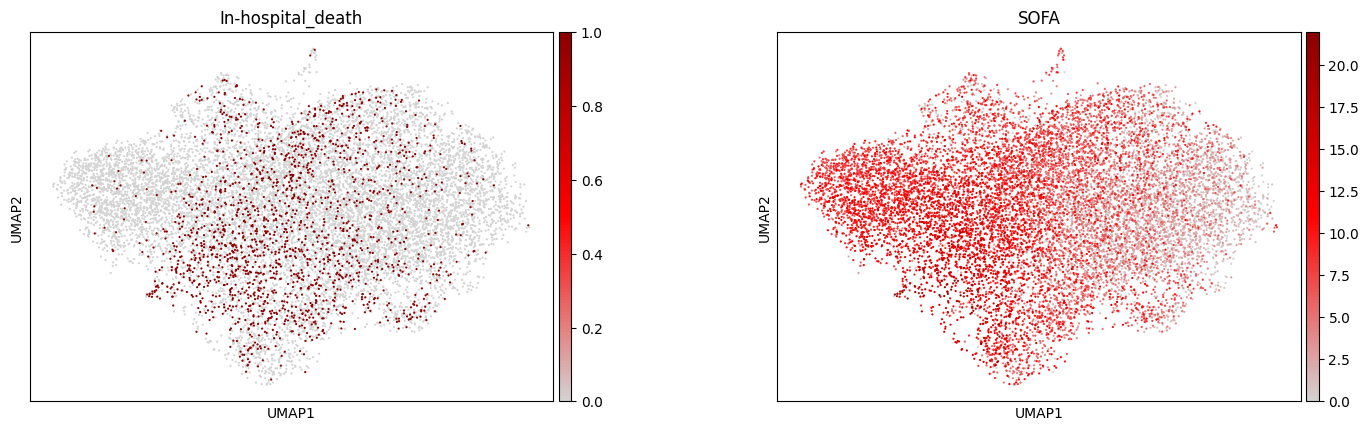

In [16]:
ep.pl.umap(edata, color=["In-hospital_death", "SOFA"], cmap=ep.pl.Colormaps.grey_red.value, wspace=0.3)

In-hospital mortality ranges from 6.4% in cluster 1 to 31.7% in cluster 3 with kidney failure, around 14.2% in all patients.
Deaths concentrate in the lower part of the embedding, where cluster 3 lies, and SOFA scores are highest in clusters 1 and 3.
Cluster 1 has the second highest median SOFA score but the lowest mortality, since organ support after cardiac surgery is planned and short, so the SOFA score overstates the risk of this subgroup.

{func}`~ehrapy.plot.trajectories` shows how the clusters differ over the 48 hours, with the mean and its 95% confidence band at every hour.
We leave out the clusters with fewer than 250 patients, whose bands are too wide to read.

In [17]:
sizes = edata.obs["leiden"].value_counts()
large = edata.obs["leiden"].isin(sizes.index[sizes >= 250]).to_numpy()
ep.pl.trajectories(
    edata[large], var_names=["GCS", "FiO2"], groupby="leiden", xlabel="hour", width=450, height=350
).cols(2)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Layout
   .Overlay.Mean_of_GCS_over_time  :Overlay
      .Area.A_0_left_parenthesis_n_equals_4273_right_parenthesis  :Area   [time]   (GCS,GCS upper)
      .Curve.A_0_left_parenthesis_n_equals_4273_right_parenthesis :Curve   [time]   (GCS)
      .Area.A_1_left_parenthesis_n_equals_2653_right_parenthesis  :Area   [time]   (GCS,GCS upper)
      .Curve.A_1_left_parenthesis_n_equals_2653_right_parenthesis :Curve   [time]   (GCS)
      .Area.A_2_left_parenthesis_n_equals_2469_right_parenthesis  :Area   [time]   (GCS,GCS upper)
      .Curve.A_2_left_parenthesis_n_equals_2469_right_parenthesis :Curve   [time]   (GCS)
      .Area.A_3_left_parenthesis_n_equals_1709_right_parenthesis  :Area   [time]   (GCS,GCS upper)
      .Curve.A_3_left_parenthesis_n_equals_1709_right_parenthesis :Curve   [time]   (GCS)
      .Area.A_4_left_parenthesis_n_equals_265_right_parenthesis   :Area   [time]   (GCS,GCS upper)
      .Curve.A_4_left_parenthesis_n_equals_265_right_parenthesis  :Curve   [time]   (GCS)
      .Area.A_5_left_parenthesis_n_equals_558_right_parenthesis   :Area   [time]   (GCS,GCS upper)
      .Curve.A_5_left_parenthesis_n_equals_558_right_parenthesis  :Curve   [time]   (GCS)
   .Overlay.Mean_of_FiO2_over_time :Overlay
      .Area.A_0_left_parenthesis_n_equals_4273_right_parenthesis  :Area   [time]   (FiO2,FiO2 upper)
      .Curve.A_0_left_parenthesis_n_equals_4273_right_parenthesis :Curve   [time]   (FiO2)
      .Area.A_1_left_parenthesis_n_equals_2653_right_parenthesis  :Area   [time]   (FiO2,FiO2 upper)
      .Curve.A_1_left_parenthesis_n_equals_2653_right_parenthesis :Curve   [time]   (FiO2)
      .Area.A_2_left_parenthesis_n_equals_2469_right_parenthesis  :Area   [time]   (FiO2,FiO2 upper)
      .Curve.A_2_left_parenthesis_n_equals_2469_right_parenthesis :Curve   [time]   (FiO2)
      .Area.A_3_left_parenthesis_n_equals_1709_right_parenthesis  :Area   [time]   (FiO2,FiO2 upper)
      .Curve.A_3_left_parenthesis_n_equals_1709_right_parenthesis :Curve   [time]   (FiO2)
      .Area.A_4_left_parenthesis_n_equals_265_right_parenthesis   :Area   [time]   (FiO2,FiO2 upper)
      .Curve.A_4_left_parenthesis_n_equals_265_right_parenthesis  :Curve   [time]   (FiO2)
      .Area.A_5_left_parenthesis_n_equals_558_right_parenthesis   :Area   [time]   (FiO2,FiO2 upper)
      .Curve.A_5_left_parenthesis_n_equals_558_right_parenthesis  :Curve   [time]   (FiO2)

Patients after cardiac surgery in cluster 1 wake up within the first day, as their GCS rises from 6 to 12, while cluster 2 stays at the lowest GCS throughout.
Cluster 4 needs a high FiO2 throughout the 48 hours, whereas it falls to about 0.5 in the other clusters within the first 12 hours.

## Conclusion

Without using the outcome, unfolded PCA of the hourly time series, a neighborhood graph and Leiden clustering found subgroups of ICU patients with distinct courses over their first 48 hours, from planned recovery after cardiac surgery to kidney failure and hypercapnia.
Their in-hospital mortality differs fivefold, and the two smallest clusters point to extreme values worth checking in the data.
The cluster of every patient is in `obs["leiden"]`, ready to stratify further analyses.